# File to do Eda and model training for conversion between MMI to PGA.

## Constants and Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

MMI_PGA_FILE_PATH = "data/processed/mmi_pga.csv"

MMI = "mmi"
PGA = "pga"
ALL_COLUMNS = [MMI, PGA]

In [4]:
df = pd.read_csv(MMI_PGA_FILE_PATH)

## Initial Dataset Exploration

In [5]:
df.shape

(380762, 2)

In [6]:
df.columns

Index(['mmi', 'pga'], dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 380762 entries, 0 to 380761
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   mmi     380762 non-null  float64
 1   pga     380762 non-null  float64
dtypes: float64(2)
memory usage: 5.8 MB


In [8]:
df.describe()

,mmi,pga
count,380762.000000,3.807620e+05
mean,3.057537,1.693561e-02
std,1.041628,4.379158e-02
min,0.000000,1.260000e-10
25%,2.200000,1.952700e-03
50%,3.100000,5.043900e-03
75%,3.600000,1.413300e-02
max,10.000000,1.644000e+00


## Histogram of MMI and PGA

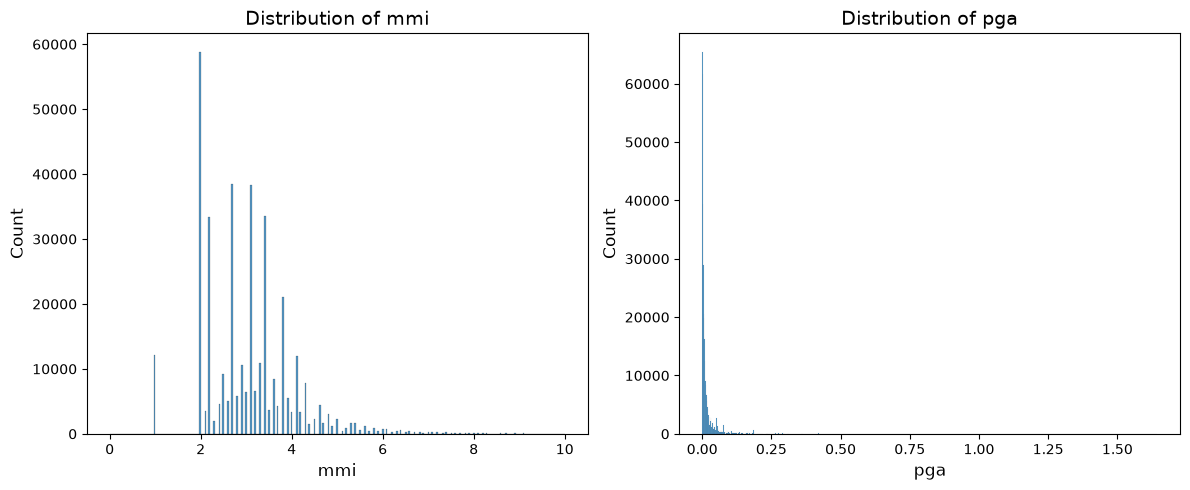

In [9]:
fig,axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
for ax,col in zip(axes.ravel(), ALL_COLUMNS):
	sns.histplot(data=df, x=col, ax=ax)
	ax.set_title(f"Distribution of {col}", fontsize=14)
	ax.set_xlabel(col, fontsize=12)
	ax.set_ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

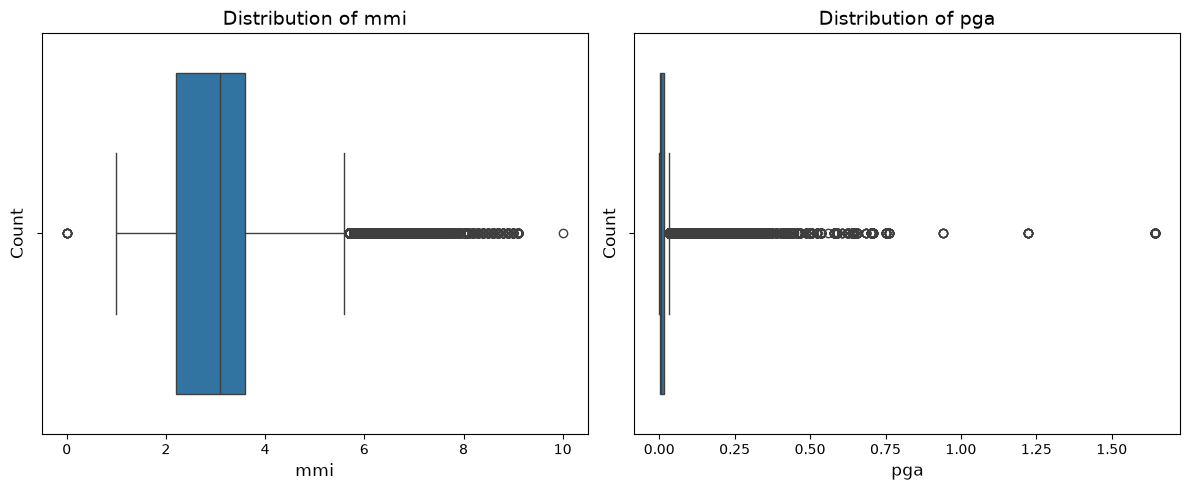

In [10]:
fig,axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
for ax,col in zip(axes.ravel(), ALL_COLUMNS):
	sns.boxplot(data=df, x=col, ax=ax)
	ax.set_title(f"Distribution of {col}", fontsize=14)
	ax.set_xlabel(col, fontsize=12)
	ax.set_ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

<Axes: xlabel='mmi', ylabel='pga'>

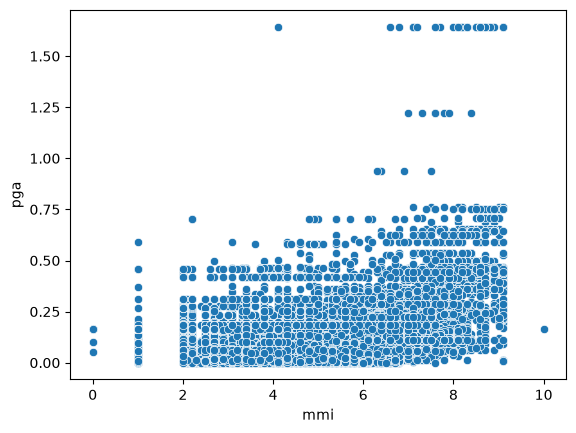

In [11]:
sns.scatterplot(data=df, x=MMI, y=PGA)

<Axes: >

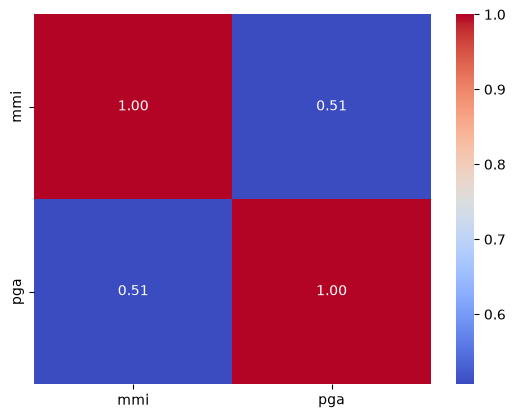

In [12]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

In [13]:
from sklearn.linear_model import (
	LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
)

def create_models() -> dict:
	"""Creates a dictionary of regression models."""
	return{
		"LinearRegression": LinearRegression(),
		"Ridge": Ridge(alpha=1.0),
		"Lasso": Lasso(alpha=0.1),
		"ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
		"BayesianRidge": BayesianRidge(),
		"HuberRegressor":HuberRegressor( max_iter=1000, alpha=0.0001)
	}


In [14]:
from typing import Any, Dict, List, Optional, Tuple
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


class ModelTrainAndEvaluator:
	"""A pipeline helper to split dataset, train multiple regression models, and evaluate performance."""

	def __init__(
		self,
		models: Dict[str, Any],
		df: pd.DataFrame,
		X_col: List[str],
		Y_col: str,
		test_size: float = 0.2,
		random_state: int = 42,
		show_full_df: bool = False
	):
		self.models = models
		self.df = df
		self.X_columns = X_col
		self.y_column = Y_col
		self.test_size = test_size
		self.random_state = random_state
		self.show_full_df = show_full_df
		self.results: Optional[pd.DataFrame] = None
		
		self.test_df: Optional[pd.DataFrame] = None
		self.test_df: Optional[pd.DataFrame] = None
		self.X_train: Optional[pd.DataFrame] = None
		self.X_test: Optional[pd.DataFrame] = None
		self.y_train: Optional[pd.Series] = None
		self.y_test: Optional[pd.Series] = None

	def split_data(
		self,
	) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
		"""Splits the dataframe into training and testing feature and target sets."""
		X = self.df[self.X_columns]
		y = self.df[self.y_column]

		self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
			X, y, test_size=self.test_size, random_state=self.random_state
		)
		self.train_df = self.df.loc[self.X_train.index]
		self.test_df = self.df.loc[self.X_test.index]
		print(f"Train Size : {self.train_df.shape}, Test Size: {self.test_df.shape}")
		return self.X_train, self.X_test, self.y_train, self.y_test


	def fit_and_evaluate(self):
			"""Trains models, prints coefficients, and calculates metrics."""
			eval_records = []
			print("\n")
			for model_name, model in self.models.items():
				# Train the model
				model.fit(self.X_train, self.y_train)

				# Extract and print coefficients
				
				string = f"{model_name} Coefficients: "
				if hasattr(model, 'coef_'):
					string += str(model.coef_)
				else:
					string += "N/A"
				if hasattr(model, 'intercept_'):
					string += f", Intercept: {model.intercept_}"
				print(string)

				# Evaluate
				pred = model.predict(self.X_test)
				train_score = model.score(self.X_train, self.y_train)
				test_score = model.score(self.X_test, self.y_test)
				
				eval_records.append({
					"model": model_name,
					"train_score": train_score,
					"test_score": test_score,
					"r2_score": r2_score(self.y_test, pred),
					"mse": mean_squared_error(self.y_test, pred),
					"mae": mean_absolute_error(self.y_test, pred),
			})
			self.eval_df = pd.DataFrame(eval_records)
			return self.eval_df

	def generate_predictions(self):
		"""Appends model predictions to the test dataframe."""
		if self.test_df is None or self.X_test is None:
			raise ValueError("Data not prepared. Call prepare_data() before generating predictions.")
		
		if self.show_full_df:
			self.predictions_df = self.test_df.copy()
		else:
			self.predictions_df = self.test_df[[self.y_column]].copy()
		
		for model_name, model in self.models.items():
			self.predictions_df[f"{model_name}_pred"] = model.predict(self.X_test)

		return self.predictions_df
	def run(self) -> Tuple[pd.DataFrame, pd.DataFrame]:
		"""Executes the complete pipeline: split -> train -> evaluate -> extract coefficients."""
		self.split_data()
		eval = self.fit_and_evaluate()
		predictions = self.generate_predictions()
		return  eval, predictions

In [15]:
models = create_models()
X_columns = [PGA]
Y_column = MMI

df_copy = df.copy()
df_copy[X_columns] = np.log10(df_copy[X_columns] + 1e-10)  # Log-transform PGA to handle skewness

mte = ModelTrainAndEvaluator(
	models=models, df=df_copy, 
	X_col=X_columns, Y_col=Y_column,
	show_full_df=True, random_state=100, test_size=0.05)
eval_1, predictions_1 = mte.run()
print(eval_1)
display(predictions_1)

del df_copy, mte, models, X_columns, Y_column

Train Size : (361723, 2), Test Size: (19039, 2)


LinearRegression Coefficients: [0.82421551], Intercept: 4.949636403290814
Ridge Coefficients: [0.82421089], Intercept: 4.949625778207893
Lasso Coefficients: [0.62114429], Intercept: 4.4833313672977955
ElasticNet Coefficients: [0.65606585], Intercept: 4.563520479802078
BayesianRidge Coefficients: [0.8242104], Intercept: 4.949624671547859
HuberRegressor Coefficients: [0.80047047], Intercept: 4.834389894800298
              model  train_score  test_score  r2_score       mse       mae
0  LinearRegression     0.308432    0.309892  0.309892  0.753613  0.652443
1             Ridge     0.308432    0.309892  0.309892  0.753613  0.652443
2             Lasso     0.289709    0.290760  0.290760  0.774506  0.659255
3        ElasticNet     0.295595    0.296715  0.296715  0.768003  0.656857
4     BayesianRidge     0.308432    0.309892  0.309892  0.753613  0.652443
5    HuberRegressor     0.304777    0.304870  0.304870  0.759098  0.650963


,mmi,pga,LinearRegression_pred,Ridge_pred,Lasso_pred,ElasticNet_pred,BayesianRidge_pred,HuberRegressor_pred
7112,8.3,-0.571153,4.478883,4.478875,4.128563,4.188807,4.478875,4.377199
7388,4.3,-1.760421,3.498670,3.498667,3.389856,3.408568,3.498667,3.425225
186372,3.8,-2.322545,3.035359,3.035359,3.040696,3.039778,3.035359,2.975261
334528,3.1,-1.891417,3.390701,3.390699,3.308488,3.322626,3.390699,3.320366
81979,2.7,-1.748970,3.508108,3.508105,3.396968,3.416081,3.508105,3.434391
...,...,...,...,...,...,...,...,...
187375,3.4,-1.465327,3.741891,3.741888,3.573152,3.602170,3.741887,3.661439
273730,3.8,-2.958965,2.510811,2.510815,2.645387,2.622245,2.510815,2.465826
221665,4.3,-1.432668,3.768809,3.768805,3.593438,3.623596,3.768805,3.687582
296546,2.5,-2.662301,2.755326,2.755328,2.829658,2.816876,2.755328,2.703296


### training for MMI <=5

In [16]:
from typing import Callable, Dict, List, Tuple, Any


def evaluate_binned_models(
	df: pd.DataFrame,
	thresholds: List[float],
	x_columns: List[str],
	y_column: str,
	create_models_fn: Callable[[], Any],
	log_transform_y: bool = True,
	eps: float = 1e-10,
	test_size: float = 0.1,
	random_state: int = 42,
	show_full_df: bool = True,
) -> Tuple[Dict[str, pd.DataFrame], Dict[str, pd.DataFrame]]:
	"""Dynamically splits df by threshold boundaries and trains/evaluates models on each bin.

	Parameters
	----------
	df : pd.DataFrame
		Input dataframe.
	thresholds : List[float]
		Array/list of split thresholds (e.g. [5.0] or [3.0, 5.0, 7.0]).
	x_columns : List[str]
		List of feature column names (e.g. [MMI]).
	y_column : str
		Target column name (e.g. PGA).
	create_models_fn : Callable
		Function that returns a fresh instance/dictionary of models.
	log_transform_y : bool, default=True
		Whether to log10 transform the Y column before training.
	eps : float, default=1e-10
		Epsilon added inside log10 transform to handle zero/skewed values.
	test_size : float, default=0.1
		Train/test split ratio.
	random_state : int, default=42
		Random state seed.
	show_full_df : bool, default=True
		Flag passed to ModelTrainAndEvaluator.

	Returns
	-------
	evaluations : Dict[str, pd.DataFrame]
		Evaluations dictionary indexed by model keys ('model_0', 'model_1',
		...).
	predictions : Dict[str, pd.DataFrame]
		Predictions dictionary indexed by model keys ('model_0', 'model_1',
		...).
	"""
	df_copy = df.copy()

	# 1. Handle Log Transformation
	if log_transform_y:
		df_copy[y_column] = np.log10(df_copy[y_column] + eps)

	# 2. Sort thresholds and build sub-dataframes
	sorted_thresholds = sorted(thresholds)
	split_col = x_columns[0]  # Primary split column

	subsets: List[pd.DataFrame] = []
	labels: List[str] = []

	# First bin: <= lowest threshold
	subsets.append(df_copy[df_copy[split_col] <= sorted_thresholds[0]])
	labels.append(f"{split_col} <= {sorted_thresholds[0]}")

	# Middle bins: t_i < split_col <= t_{i+1}
	for i in range(len(sorted_thresholds) - 1):
		t_low, t_high = sorted_thresholds[i], sorted_thresholds[i + 1]
		mask = (df_copy[split_col] > t_low) & (df_copy[split_col] <= t_high)
		subsets.append(df_copy[mask])
		labels.append(f"{t_low} < {split_col} <= {t_high}")

	# Last bin: > highest threshold
	subsets.append(df_copy[df_copy[split_col] > sorted_thresholds[-1]])
	labels.append(f"{split_col} > {sorted_thresholds[-1]}")

	evaluations: Dict[str, pd.DataFrame] = {}
	predictions: Dict[str, pd.DataFrame] = {}

	# 3. Train and evaluate for each bin
	for idx, (df_sub, label) in enumerate(zip(subsets, labels)):
		model_key = f"model_{idx}"

		print("\n" + "=" * 50)
		print(
			f"  {model_key.upper()}: Evaluation for {label} (Samples: {len(df_sub)})"
		)
		print("=" * 50)

		if len(df_sub) == 0:
			print(f"Warning: No data points in bin ({label}). Skipping...")
			continue

		# Instantiate fresh model set
		models = create_models_fn()

		mte = ModelTrainAndEvaluator(
			models=models,
			df=df_sub,
			X_col=x_columns,
			Y_col=y_column,
			show_full_df=show_full_df,
			random_state=random_state,
			test_size=test_size,
		)

		eval_df, pred_df = mte.run()

		evaluations[model_key] = eval_df
		predictions[model_key] = pred_df

		print(eval_df)

	return evaluations, predictions

In [17]:
thresholds = [5.0]  # Example thresholds for MMI

# Formula: MMI ~ a + b * log10(PGA)
# or log10(PGA) = (MMI - a) / b
# or log10(PGA) = c * MMI + d, where c = 1/b and d = -a/b
# this formula is being used to convert MMI to PGA values for the purpose of training and evaluating models.

evaluations, predictions = evaluate_binned_models(
	df=df,
	thresholds=thresholds,
	x_columns=[MMI],
	y_column=PGA,
	create_models_fn=create_models,
	random_state=42,
	test_size=0.1,
)



  MODEL_0: Evaluation for mmi <= 5.0 (Samples: 365704)
Train Size : (329133, 2), Test Size: (36571, 2)


LinearRegression Coefficients: [0.38123501], Intercept: -3.459914008821499
Ridge Coefficients: [0.38123335], Intercept: -3.4599091318320108
Lasso Coefficients: [0.23758892], Intercept: -3.0388652769233433
ElasticNet Coefficients: [0.28867822], Intercept: -3.1886158440913115
BayesianRidge Coefficients: [0.38123107], Intercept: -3.4599024584593625
HuberRegressor Coefficients: [0.39430029], Intercept: -3.46583608267226
              model  train_score  test_score  r2_score       mse       mae
0  LinearRegression     0.227167    0.229316  0.229316  0.347915  0.434637
1             Ridge     0.227167    0.229316  0.229316  0.347915  0.434637
2             Lasso     0.194916    0.195629  0.195629  0.363123  0.448369
3        ElasticNet     0.213777    0.214914  0.214914  0.354417  0.441149
4     BayesianRidge     0.227167    0.229316  0.229316  0.347916  0.434637
5    HuberRegressor     

In [18]:
thresholds = [3.0,6.0]  # Example thresholds for MMI

evaluations, predictions = evaluate_binned_models(
	df=df,
	thresholds=thresholds,
	x_columns=[MMI],
	y_column=PGA,
	create_models_fn=create_models,
	random_state=42,
	test_size=0.1,
)



  MODEL_0: Evaluation for mmi <= 3.0 (Samples: 189874)
Train Size : (170886, 2), Test Size: (18988, 2)


LinearRegression Coefficients: [0.35137835], Intercept: -3.389829296331652
Ridge Coefficients: [0.35136901], Intercept: -3.389808020157444
Lasso Coefficients: [0.], Intercept: -2.590115882201492
ElasticNet Coefficients: [0.10107621], Intercept: -2.8201585034837917
BayesianRidge Coefficients: [0.35135232], Intercept: -3.3897700460143456
HuberRegressor Coefficients: [0.34745649], Intercept: -3.3556569039248205
              model  train_score  test_score  r2_score       mse       mae
0  LinearRegression     0.073201    0.084223  0.084223  0.333547  0.422553
1             Ridge     0.073201    0.084223  0.084223  0.333547  0.422553
2             Lasso     0.000000   -0.000020 -0.000020  0.364230  0.445216
3        ElasticNet     0.036057    0.039355  0.039355  0.349889  0.434571
4     BayesianRidge     0.073201    0.084222  0.084222  0.333547  0.422553
5    HuberRegressor     0.071474

In [19]:
from typing import Callable, Dict, List

import numpy as np
import pandas as pd


def pga_piecewise_independent(
	mmi: float,
	thresholds: List[float],
	configs: List[Dict[str, float]],
) -> float:
	"""Calculate PGA (in g) for N independent segments defined by split thresholds."""
	sorted_thresholds = sorted(thresholds)

	segment_idx = 0
	for t in sorted_thresholds:
		if mmi <= t:
			break
		segment_idx += 1

	conf = configs[segment_idx]
	log_pga = conf["intercept"] + conf["slope"] * mmi

	return 10**log_pga


# --- Single Huber Baseline ---
HUBER_INTERCEPT = -3.428060822095887
HUBER_SLOPE = 0.3809512


# --- HuberRegressor 2-Segment Parameters (Split at MMI = 5.0) ---
THRESHOLDS_2SEG = [5.0]

HUBER_2SEG_CONFIGS = [
	{
		"intercept": -3.46583608267226,
		"slope": 0.39430029,
	},  # MODEL_0: MMI <= 5.0
	{
		"intercept": -2.820426218668717,
		"slope": 0.27948089,
	},  # MODEL_1: MMI > 5.0
]


# --- HuberRegressor 3-Segment Parameters (Splits at MMI = [3.0, 6.0]) ---
THRESHOLDS_3SEG = [3.0, 6.0]

HUBER_3SEG_CONFIGS = [
	{
		"intercept": -3.3556569039248205,
		"slope": 0.34745649,
	},  # MODEL_0: MMI <= 3.0
	{
		"intercept": -3.582987153443698,
		"slope": 0.42501688,
	},  # MODEL_1: 3.0 < MMI <= 6.0
	{
		"intercept": -2.7643686183763827,
		"slope": 0.27199952,
	},  # MODEL_2: MMI > 6.0
]


pga_funcs: Dict[str, Callable[[float], float]] = {
	"Single Huber": lambda mmi: 10 ** (
		HUBER_INTERCEPT + HUBER_SLOPE * mmi
	),
	"Piecewise Huber (2-Seg)": lambda mmi: pga_piecewise_independent(
		mmi,
		thresholds=THRESHOLDS_2SEG,
		configs=HUBER_2SEG_CONFIGS,
	),
	"Piecewise Huber (3-Seg)": lambda mmi: pga_piecewise_independent(
		mmi,
		thresholds=THRESHOLDS_3SEG,
		configs=HUBER_3SEG_CONFIGS,
	),
}


def evaluate_pga_models(
	df: pd.DataFrame,
	pga_funcs: Dict[str, Callable[[float], float]],
	target_mmis: np.ndarray = np.arange(2.0, 8.5, 0.5),
	mmi_col: str = "MMI",
	pga_col: str = "PGA",
) -> pd.DataFrame:
	"""Compare empirical PGA medians with predictions from multiple models.

	For each target MMI, the empirical median PGA is calculated from the
	dataset and compared against each model prediction. Overall MAE, MAPE,
	and RMSE are also calculated across all evaluated MMI values.

	Args:
		df: Input dataframe containing MMI and PGA observations.
		pga_funcs: Dictionary mapping model names to MMI-to-PGA functions.
		target_mmis: MMI values at which models are evaluated.
		mmi_col: Name of the MMI column.
		pga_col: Name of the PGA column.

	Returns:
		DataFrame containing empirical medians, model predictions, and
		percentage errors for each target MMI.
	"""
	df_temp = df.copy()

	# Round MMI values so that discrete half-unit intensities can be matched.
	df_temp["mmi_rounded"] = df_temp[mmi_col].round(1)

	# Calculate empirical PGA statistics for each MMI value.
	mmi_pga_stats = (
		df_temp.groupby("mmi_rounded")[pga_col]
		.agg(
			count="count",
			median="median",
			mean="mean",
			std="std",
			min="min",
			max="max",
		)
		.reset_index()
		.sort_values("mmi_rounded")
	)

	comparison_data = []

	# Evaluate every model at every target MMI.
	for target_mmi in target_mmis:
		target_mmi = round(float(target_mmi), 1)

		rows = mmi_pga_stats[
			mmi_pga_stats["mmi_rounded"] == target_mmi
		]

		if not rows.empty:
			row = rows.iloc[0]
			matched_mmi = row["mmi_rounded"]
			empirical_median = row["median"]
			sample_count = int(row["count"])
			match_type = "Exact"

		else:
			# Use the closest available MMI if an exact value is unavailable.
			idx = (
				mmi_pga_stats["mmi_rounded"] - target_mmi
			).abs().idxmin()

			row = mmi_pga_stats.loc[idx]
			matched_mmi = row["mmi_rounded"]
			empirical_median = row["median"]
			sample_count = int(row["count"])
			match_type = "Nearest"

		entry = {
			"Target MMI": target_mmi,
			"Matched MMI": matched_mmi,
			"Match Type": match_type,
			"Samples": sample_count,
			"Empirical Median (g)": empirical_median,
		}

		for name, func in pga_funcs.items():
			calc_pga_g = func(target_mmi)

			diff = calc_pga_g - empirical_median

			pct_err = (
				(diff / empirical_median) * 100
				if empirical_median != 0
				else np.nan
			)

			entry[f"{name} (g)"] = calc_pga_g
			entry[f"{name} Err %"] = pct_err

		comparison_data.append(entry)

	comparison_df = pd.DataFrame(comparison_data)

	# ------------------------------------------------------------------
	# Overall error metrics
	# ------------------------------------------------------------------
	metrics = {}

	actual = comparison_df["Empirical Median (g)"].to_numpy()

	for name in pga_funcs.keys():
		predicted = comparison_df[f"{name} (g)"].to_numpy()

		errors = predicted - actual

		# Mean Absolute Error
		mae = np.mean(np.abs(errors))

		# Root Mean Squared Error
		rmse = np.sqrt(np.mean(errors**2))

		# Mean Absolute Percentage Error
		# Exclude zero empirical values to avoid division by zero.
		nonzero = actual != 0

		if np.any(nonzero):
			mape = (
				np.mean(
					np.abs(
						errors[nonzero] / actual[nonzero]
					)
				)
				* 100
			)
		else:
			mape = np.nan

		metrics[name] = {
			"MAE (g)": mae,
			"MAPE (%)": mape,
			"RMSE (g)": rmse,
		}

	# ------------------------------------------------------------------
	# Format comparison table for display
	# ------------------------------------------------------------------
	formatted_df = comparison_df.copy()

	for col in ["Target MMI", "Matched MMI"]:
		formatted_df[col] = formatted_df[col].map("{:.1f}".format)

	formatted_df["Empirical Median (g)"] = formatted_df[
		"Empirical Median (g)"
	].map("{:.6f}".format)

	for name in pga_funcs.keys():
		formatted_df[f"{name} (g)"] = formatted_df[
			f"{name} (g)"
		].map("{:.6f}".format)

		formatted_df[f"{name} Err %"] = formatted_df[
			f"{name} Err %"
		].map("{:+.2f}%".format)

	# ------------------------------------------------------------------
	# Final metric summary
	# ------------------------------------------------------------------
	print("\n" + "=" * 75)
	print("Overall Model Error Metrics")
	print("=" * 75)

	for name, metric in metrics.items():
		print(
			f"{name:<28} "
			f"MAE: {metric['MAE (g)']:.6f} g | "
			f"MAPE: {metric['MAPE (%)']:.2f}% | "
			f"RMSE: {metric['RMSE (g)']:.6f} g"
		)

	print("=" * 75)

	return formatted_df


comparison_results = evaluate_pga_models(
	df,
	pga_funcs,
	mmi_col=MMI,
	pga_col=PGA,
)

print(comparison_results)
display(comparison_results)


Overall Model Error Metrics
Single Huber                 MAE: 0.021551 g | MAPE: 19.59% | RMSE: 0.044127 g
Piecewise Huber (2-Seg)      MAE: 0.005381 g | MAPE: 10.94% | RMSE: 0.008026 g
Piecewise Huber (3-Seg)      MAE: 0.006474 g | MAPE: 11.93% | RMSE: 0.010172 g
   Target MMI Matched MMI Match Type  Samples Empirical Median (g)  \
0         2.0         2.0      Exact    58777             0.002269   
1         2.5         2.5      Exact     9233             0.003129   
2         3.0         3.0      Exact     6426             0.005518   
3         3.5         3.5      Exact     3729             0.010398   
4         4.0         4.0      Exact     3386             0.018992   
5         4.5         4.5      Exact     2244             0.027748   
6         5.0         5.0      Exact     2359             0.034652   
7         5.5         5.5      Exact      653             0.058811   
8         6.0         6.0      Exact      767             0.069783   
9         6.5         6.5      Exa

,Target MMI,Matched MMI,Match Type,Samples,Empirical Median (g),Single Huber (g),Single Huber Err %,Piecewise Huber (2-Seg) (g),Piecewise Huber (2-Seg) Err %,Piecewise Huber (3-Seg) (g),Piecewise Huber (3-Seg) Err %
0,2.0,2.0,Exact,58777,0.002269,0.002157,-4.92%,0.002103,-7.31%,0.002184,-3.73%
1,2.5,2.5,Exact,9233,0.003129,0.003344,+6.89%,0.003311,+5.81%,0.003258,+4.14%
2,3.0,3.0,Exact,6426,0.005518,0.005186,-6.03%,0.005213,-5.53%,0.004861,-11.91%
3,3.5,3.5,Exact,3729,0.010398,0.008040,-22.67%,0.008208,-21.06%,0.008027,-22.80%
4,4.0,4.0,Exact,3386,0.018992,0.012466,-34.36%,0.012923,-31.96%,0.013094,-31.05%
5,4.5,4.5,Exact,2244,0.027748,0.019329,-30.34%,0.020348,-26.67%,0.021359,-23.02%
6,5.0,5.0,Exact,2359,0.034652,0.029971,-13.51%,0.032038,-7.54%,0.034842,+0.55%
7,5.5,5.5,Exact,653,0.058811,0.046470,-20.98%,0.052086,-11.44%,0.056834,-3.36%
8,6.0,6.0,Exact,767,0.069783,0.072052,+3.25%,0.071855,+2.97%,0.092707,+32.85%
9,6.5,6.5,Exact,343,0.106160,0.111718,+5.24%,0.099129,-6.62%,0.100839,-5.01%


In [20]:
def mmi_to_pga(mmi: float) -> float:
    """Convert Modified Mercalli Intensity (MMI) to estimated PGA in g.

    Derived from HuberRegressor models fitted to the STEPPS MMI-PGA dataset.
    The original empirical relationship is:

        MMI ≈ a + b * log10(PGA)

    Rearranging gives:

        log10(PGA) = (MMI - a) / b
                   = c * MMI + d

    where:

        c = 1 / b
        d = -a / b

    The models were trained directly in log-space as:

        log10(PGA) = slope * MMI + intercept

    A piecewise formulation was used with separate fits for MMI <= 5.0
    and MMI > 5.0. PGA is then recovered as:

        PGA = 10^(slope * MMI + intercept)

    The two-segment model was selected because it produced lower MAE, MAPE,
    and RMSE than the single- and three-segment alternatives. The residual
    error around MMI 4-5 is influenced by the large number of observations
    in this range and their observed PGA spread.

    This provides a practical continuous approximation for converting MMI
    thresholds to PGA thresholds in later STEPPS processing, training, and
    evaluation stages, rather than a universal physical MMI-PGA relationship.

    Args:
        mmi (float): Modified Mercalli Intensity value.

    Returns:
        float: Estimated Peak Ground Acceleration (PGA) in units of g.
    """
    if mmi <= 5.0:
        intercept = -3.46583608267226
        slope = 0.39430029
    else:
        intercept = -2.820426218668717
        slope = 0.27948089

    return 10 ** (intercept + slope * mmi)

In [21]:
MMIS = np.arange(2.0, 8.5, 0.5)

df_grouped = df.groupby(MMI)[PGA].agg(
    count="count",
    median="median",
    mean="mean",
    std="std",
    min="min",
    max="max"
).reset_index()

result_dict: dict[float, float] = {}

for mmi in MMIS:
    empirical_row = df_grouped[df_grouped[MMI] == mmi]

    result_dict[float(mmi)] = (
        float(empirical_row["median"].iloc[0])
        if not empirical_row.empty
        else float("nan")
    )

print("Lookup = {")
for i, (mmi, pga) in enumerate(result_dict.items()):
    comma = "," if i < len(result_dict) - 1 else ""
    print(f"    {mmi:.1f}: {pga}{comma}")
print("}")

Lookup = {
    2.0: 0.002268553,
    2.5: 0.00312874,
    3.0: 0.0055180005,
    3.5: 0.010397652,
    4.0: 0.018992,
    4.5: 0.027748000000000002,
    5.0: 0.034651877,
    5.5: 0.058811,
    6.0: 0.069783,
    6.5: 0.10616,
    7.0: 0.13697,
    7.5: 0.20955,
    8.0: 0.27436
}
